conv_result1:
[[21 32 26 23]
 [24 37 41 28]
 [21 29 33 30]
 [ 7 15 20 16]]
conv_result2:
[[21 32 27 22]
 [24 37 38 25]
 [20 29 28 27]
 [ 8 12 21 11]]
dct_result1:
[[2.48490665 0.69471389 0.91629073 0.91545225]
 [1.22052166 0.9568772  0.10623698 0.55961579]
 [0.69314718 0.61227503 0.40546511 0.54958728]
 [1.12230597 0.55961579 0.94668841 0.63998193]]
dct_result2:
[[2.44234704 0.54958728 0.69314718 0.61227503]
 [1.34830557 0.91629073 0.29999672 0.99588046]
 [0.         0.61227503 0.40546511 0.54958728]
 [1.18273023 0.25688251 1.01830664 0.91629073]]
conv_similarity: 0.9969911051506668
dct_similarity: 0.9648004895580078


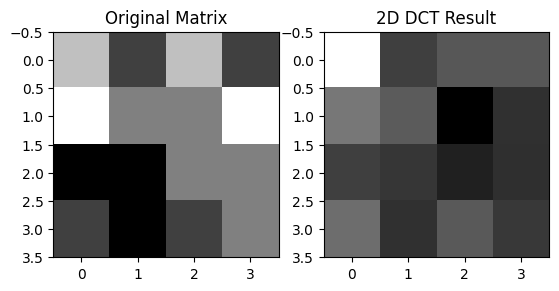

In [2]:
import numpy as np
from scipy.signal import convolve2d
from scipy.fftpack import dctn
import matplotlib.pyplot as plt


def conv_calculate(input_matrix, kernel):
    result = convolve2d(input_matrix, kernel, mode='same')
    return result

def DCT_calculate(input_matrix):
    dct_result = dctn(input_matrix, type=2, norm='ortho')
    dct_result = np.log(1+abs(dct_result))
    return dct_result


def matrix_similarity(matrix1, matrix2):
    vector1 = matrix1.flatten()
    vector2 = matrix2.flatten()

    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity

input_matrix1 = np.array([[4,2,4,2],[5,3,3,5],[1,1,3,3],[2,1,2,3]])
input_matrix3 = np.array([[4,2,4,3],[5,3,3,4],[1,1,3,1],[1,2,1,4]])
input_matrix2 = np.array([[4,2,4,2],[5,3,3,5],[3,1,1,3],[2,1,2,3]])

kernel = np.array([[1,2,1],[2,1,2],[1,2,1]])

conv_result1 = conv_calculate(input_matrix1, kernel)
conv_result2 = conv_calculate(input_matrix3, kernel)
print('conv_result1:')
print(conv_result1)
print('conv_result2:')
print(conv_result2)

dct_result1 = DCT_calculate(input_matrix1)
dct_result2 = DCT_calculate(input_matrix3)
print('dct_result1:')
print(dct_result1)
print('dct_result2:')
print(dct_result2)

conv_similarity = matrix_similarity(conv_result1, conv_result2)
dct_similarity = matrix_similarity(dct_result1, dct_result2)
print('conv_similarity:', conv_similarity)
print('dct_similarity:', dct_similarity)

plt.subplot(1, 2, 1)
plt.title("Original Matrix")
plt.imshow(input_matrix1, cmap='gray', interpolation='nearest')

plt.subplot(1, 2, 2)
plt.title("2D DCT Result")
plt.imshow(dct_result1, cmap='gray', interpolation='nearest')

plt.show()